In [3]:
import pandas as pd
import numpy as np

In [4]:
file = r'cryptos.csv'
data = pd.read_csv(file, index_col="ate", parse_dates=True)

FileNotFoundError: [Errno 2] No such file or directory: 'cryptos.csv'

In [ ]:
log_returns = np.log(data / data.shift(1))

In [ ]:
log_returns.dropna(inplace=True)

In [ ]:
log_returns

,BTC,ETH,BNB,XRP,ADA,SOL,DOGE,TRX,TON,MATIC,...,LTC,AVAX,DAI,LINK,LEO,XLM,WSTETH,HBAR,SHIB,BCH
ate,,,,,,,,,,,,,,,,,,,,,
2021-10-08 00:00:00+00:00,0.003004,-0.006772,-0.045842,-0.004819,-0.017642,0.029808,0.003813,0.022322,0.063502,0.051543,...,-0.015783,-0.015870,-0.000322,-0.016271,-0.041809,-0.024401,-0.011684,-0.011430,0.160343,-0.027129
2021-10-09 00:00:00+00:00,0.018367,0.003350,0.005823,0.087364,0.013073,-0.013449,0.011194,0.051872,0.047178,0.005278,...,0.020732,0.000760,0.000956,0.037766,0.020624,0.049545,0.004256,-0.007388,0.000000,0.030923
2021-10-10 00:00:00+00:00,-0.003584,-0.042815,-0.039879,-0.018686,-0.031097,-0.057595,-0.070520,-0.051073,-0.068982,-0.079266,...,-0.024454,-0.067842,-0.000568,-0.066664,-0.024697,-0.059406,-0.030926,-0.076748,-0.037740,-0.046366
2021-10-11 00:00:00+00:00,0.048349,0.034288,0.020493,-0.000496,-0.010902,-0.021786,0.007362,-0.006013,-0.056205,-0.003572,...,0.023158,-0.023039,0.000204,-0.015327,-0.009504,0.035566,0.008921,0.000774,0.175891,0.025528
2021-10-12 00:00:00+00:00,-0.025436,-0.014999,0.070975,-0.032175,-0.025254,0.052963,-0.022988,-0.017159,-0.031945,-0.016091,...,-0.037641,-0.017265,-0.000404,-0.025468,0.021992,-0.033691,-0.008428,0.018742,-0.066691,-0.024153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-10 00:00:00+00:00,-0.026005,-0.079677,-0.041339,-0.056015,-0.068312,-0.066578,-0.085449,-0.010499,-1.954538,-0.062545,...,-0.075992,-0.097725,0.000149,-0.081678,0.001390,-0.081083,-0.069612,-0.050610,0.000000,-0.074310
2025-03-11 00:00:00+00:00,0.053673,0.031049,0.035723,0.071052,0.071691,0.057269,0.063536,-0.022296,0.267772,0.040063,...,0.031198,0.070451,-0.000042,0.031542,0.013769,0.051177,0.026265,0.033083,0.000000,0.023384
2025-03-12 00:00:00+00:00,0.010327,-0.005674,0.032856,0.033508,0.017637,0.010477,0.048829,-0.006397,-0.174338,0.004233,...,0.012726,0.078362,0.000005,0.028780,-0.017723,0.017738,-0.012514,0.025976,0.000000,0.041728


In [ ]:
corr_matrix = log_returns.corr(method='kendall')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

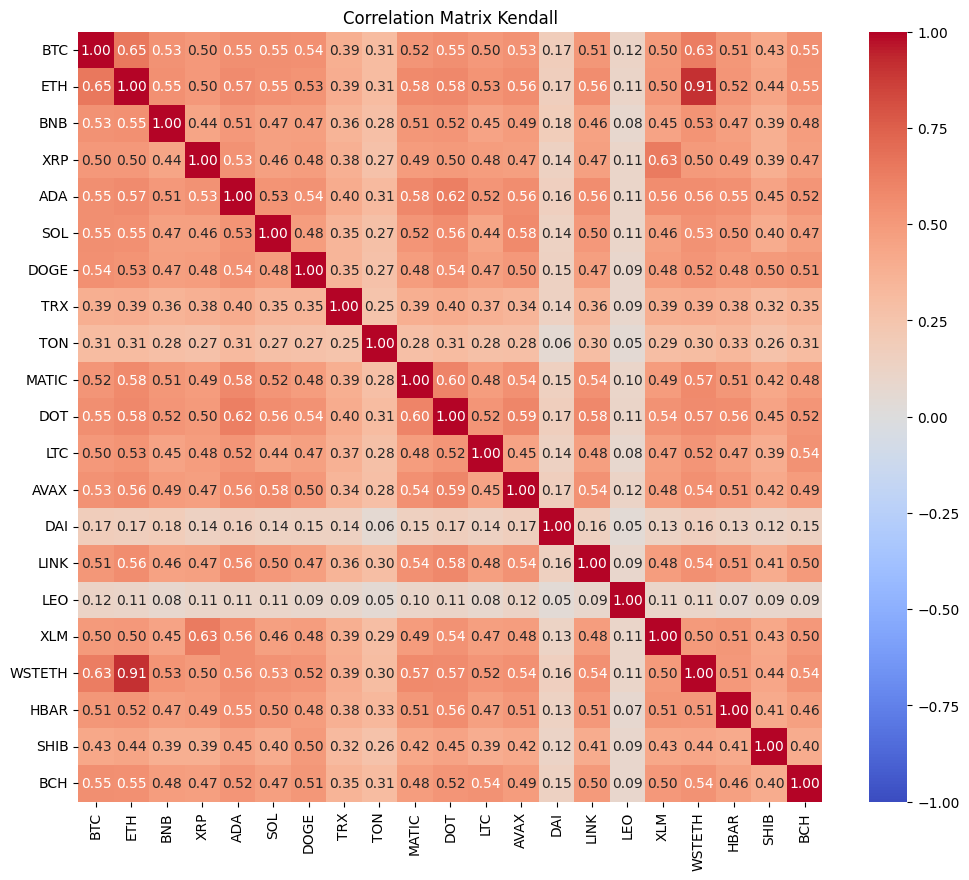

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix Kendall")
plt.savefig("correlation_matrix_kendall.svg", format='svg', bbox_inches='tight')
plt.show()

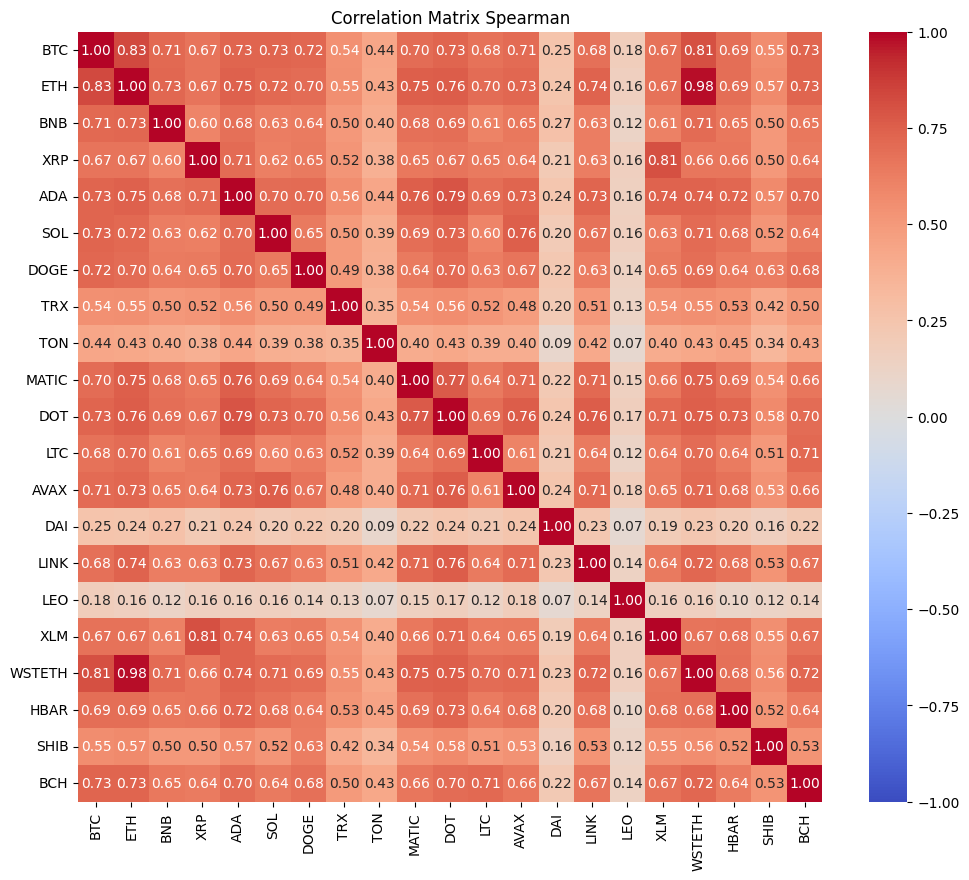

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(log_returns.corr(method='spearman'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix Spearman")
plt.savefig("correlation_matrix_spearman.svg", format='svg', bbox_inches='tight')
plt.show()

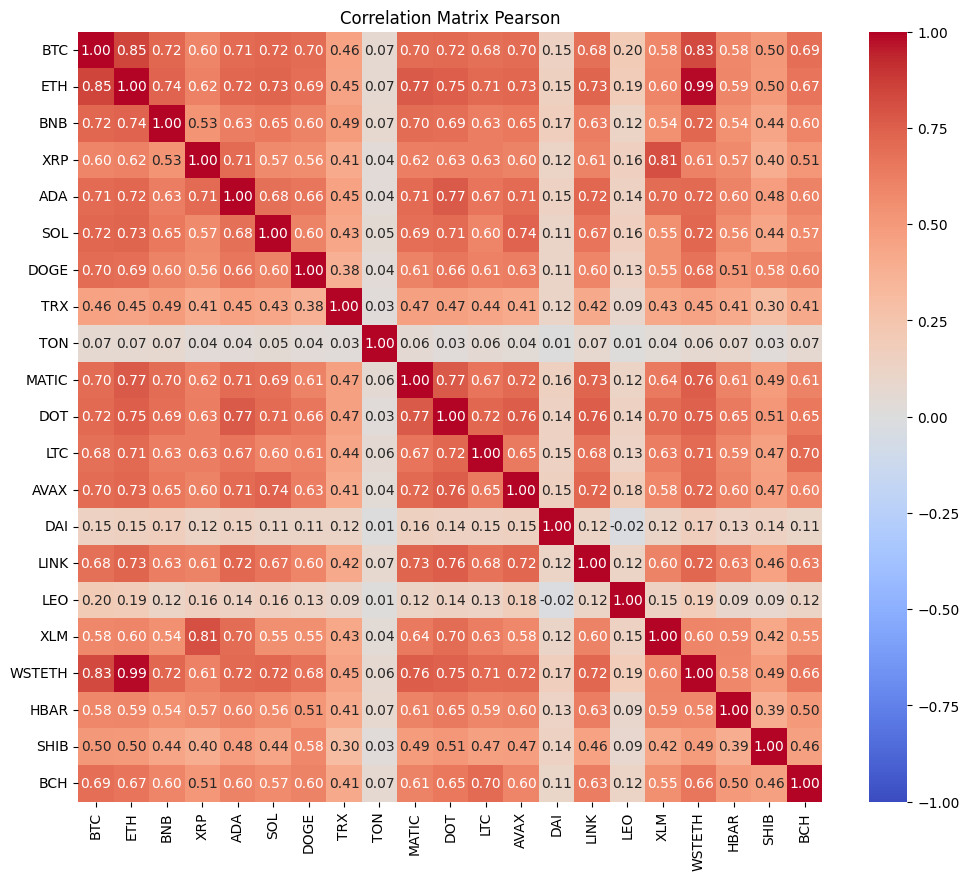

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(log_returns.corr(method='pearson'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix Pearson")
plt.savefig("correlation_matrix_pearson.svg", format='svg', bbox_inches='tight')
plt.show()

Nos quedamos con la Pearson

In [ ]:
corr=log_returns.corr(method='pearson')

# **GRAFOS**

In [ ]:
# GRAFO DE CORRELAÇÃO
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# **CONECTARLOS SI TIENEN CORRELACION SPEARMAN MAYOR A 0.7**

In [ ]:
# Create a graph from the correlation matrix
G = nx.Graph()

In [ ]:
threshold = 0.7

In [ ]:
# Add edges to the graph based on the correlation values
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            G.add_edge(corr.columns[i], corr.columns[j], weight=corr.iloc[i, j])

In [ ]:
# add the nodes in the graph that are not connected
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) < threshold:
            G.add_node(corr.columns[i])
            G.add_node(corr.columns[j])

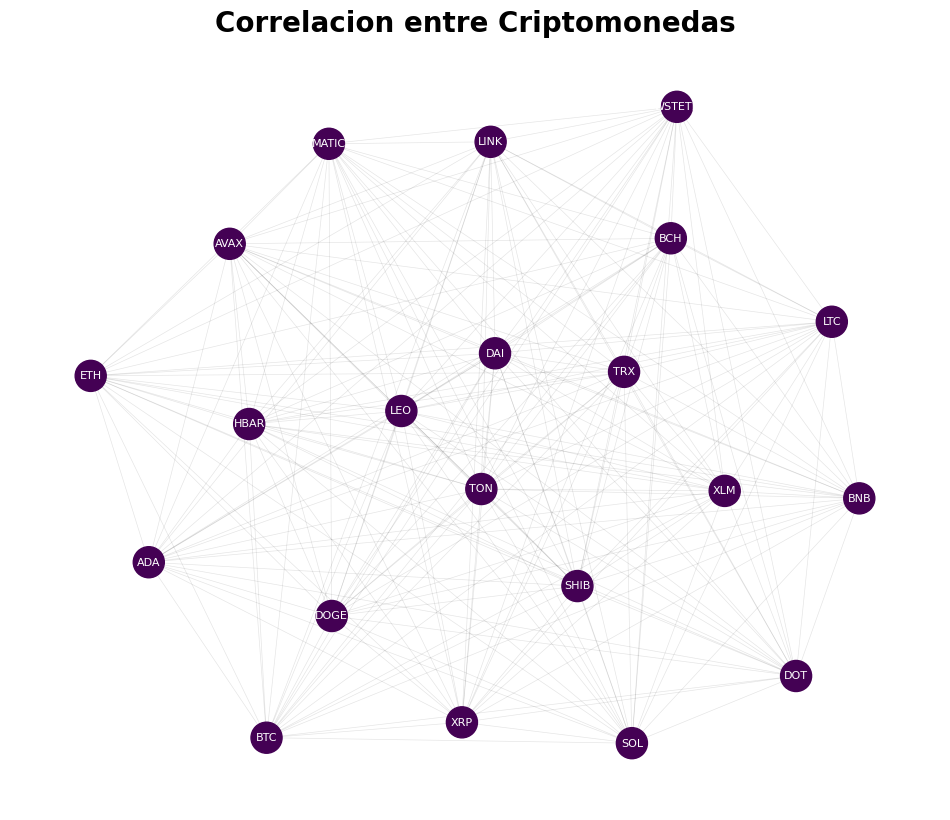

In [ ]:
# Set node colors based on degree
node_colors = [G.degree(node) for node in G.nodes()]

# Draw the graph
pos = nx.spring_layout(G)
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500)

nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.1)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
plt.axis('off')
plt.title("Correlacion entre Criptomonedas", fontsize=20, fontweight='bold')

plt.savefig("correlation_graph.svg", format='svg', bbox_inches='tight')
plt.show()

## **CONECTARLOS Y ALEJARLOS DEPENDIENDO DE LOS PESOS**

In [ ]:
# Create a graph from the correlation matrix
G = nx.Graph()

In [ ]:
dist_corr = 1 - abs(corr)

In [ ]:
# Add edges to the graph based on the correlation values
for i in range(len(corr.columns)):
    for j in range(i):
        G.add_edge(dist_corr.columns[i], dist_corr.columns[j], weight=dist_corr.iloc[i, j])

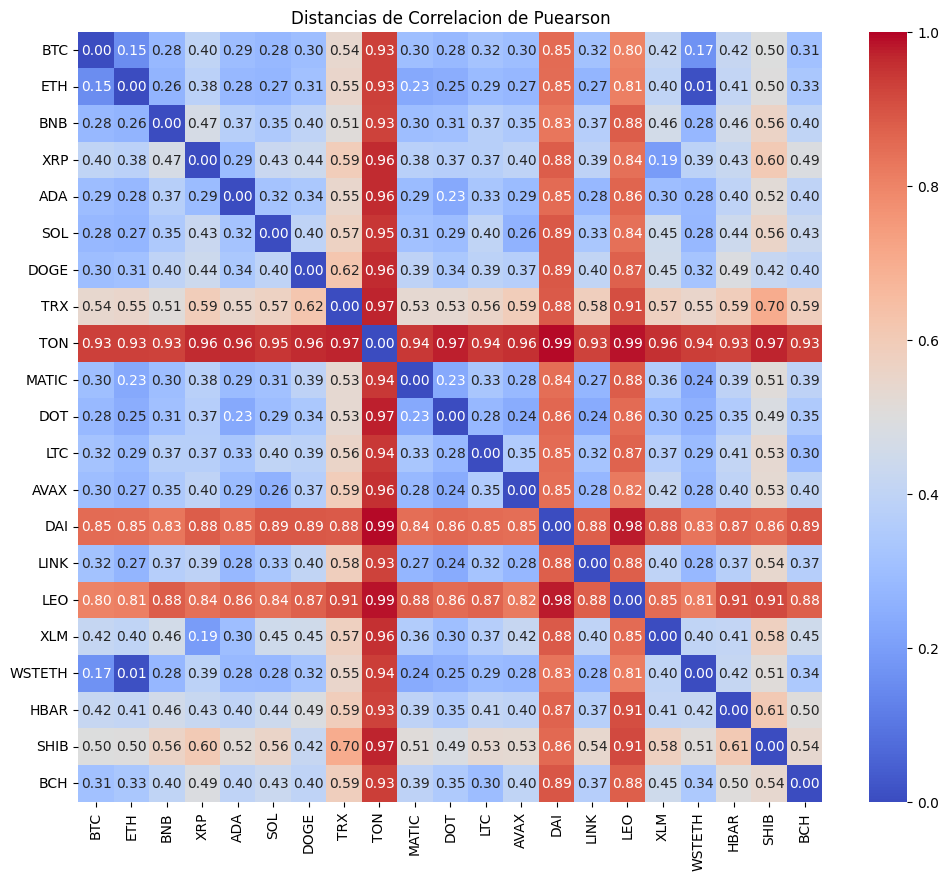

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(dist_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Distancias de Correlacion de Puearson")
plt.savefig("d-correlation_matrix_pearson.svg", format='svg', bbox_inches='tight')
plt.show()

In [ ]:
classification = {
    'BTC': 'Mayor Cap. Mercado',
    'ETH': 'Mayor Cap. Mercado',
    'USDT': 'Stablecoins',
    'BNB': 'Mayor Cap. Mercado',
    'USDC': 'Stablecoins',
    'XRP': 'Mayor Cap. Mercado',
    'ADA': 'Mayor Cap. Mercado',
    'SOL': 'Mayor Cap. Mercado',
    'DOGE': 'Memecoins',
    'DAI': 'Stablecoins',
    'TRX': 'Tokens Blockchain',
    'TON': 'Tokens Blockchain',
    'MATIC': 'Tokens Blockchain',
    'DOT': 'Tokens Blockchain',
    'AVAX': 'Tokens Blockchain',
    'STETH': 'Tokens Blockchain',
    'WSTETH': 'Activos Envueltos',
    'SUI': 'Tokens Blockchain',
    'WBTC': 'Activos Envueltos',
    'WTRX': 'Activos Envueltos',
    'LTC': 'Pagos & DeFi',
    'LINK': 'Pagos & DeFi',
    'XLM': 'Pagos & DeFi',
    'HBAR': 'Pagos & DeFi',
    'BCH': 'Pagos & DeFi',
    'SHIB': 'Memecoins',
    'LEO': 'Tokens de Exchange'
}

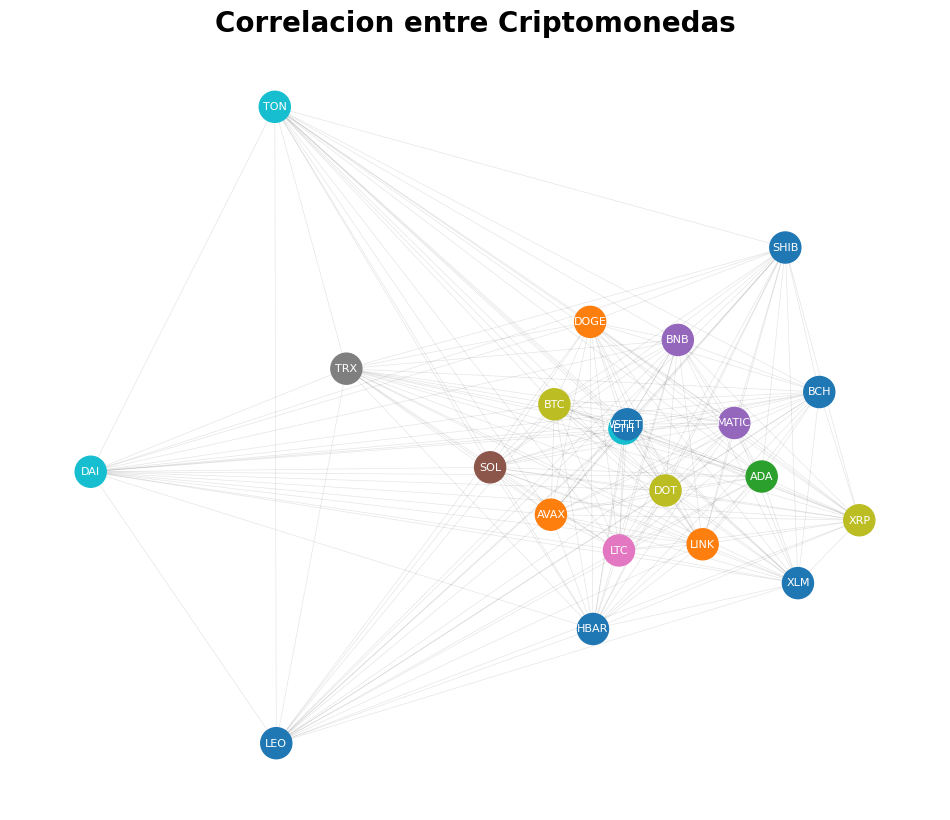

In [ ]:
# nx Kamada Kaway layout
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=cm.tab10, node_size=500)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.1)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
plt.axis('off')
plt.title("Correlacion entre Criptomonedas", fontsize=20, fontweight='bold')
plt.savefig("correlation_graph_kamada.svg", format='svg', bbox_inches='tight')
plt.show()

In [ ]:
G.edges(data=True)

EdgeDataView([('ETH', 'BTC', {'weight': np.float64(0.15261690199809752)}), ('ETH', 'BNB', {'weight': np.float64(0.2620060975240015)}), ('ETH', 'XRP', {'weight': np.float64(0.3830615080883253)}), ('ETH', 'ADA', {'weight': np.float64(0.2775602388421783)}), ('ETH', 'SOL', {'weight': np.float64(0.27128042811516295)}), ('ETH', 'DOGE', {'weight': np.float64(0.3124480142289602)}), ('ETH', 'TRX', {'weight': np.float64(0.5501911701289077)}), ('ETH', 'TON', {'weight': np.float64(0.9311845450020599)}), ('ETH', 'MATIC', {'weight': np.float64(0.2309025151574211)}), ('ETH', 'DOT', {'weight': np.float64(0.24526582713816103)}), ('ETH', 'LTC', {'weight': np.float64(0.28605834384927376)}), ('ETH', 'AVAX', {'weight': np.float64(0.27357304873549304)}), ('ETH', 'DAI', {'weight': np.float64(0.8515310272653371)}), ('ETH', 'LINK', {'weight': np.float64(0.26614454024515966)}), ('ETH', 'LEO', {'weight': np.float64(0.8123359291555494)}), ('ETH', 'XLM', {'weight': np.float64(0.3997933693104938)}), ('ETH', 'WSTETH

# **GRAFO DE CAUSALIDAD**

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Perform the Granger causality test with a maximum lag of 4
# The test checks if BTC (first column) Granger-causes ETH (second column)
grangercausalitytests(data[['BTC', 'ETH']], maxlag=4, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.3270  , p=0.0684  , df_denom=1251, df_num=1
ssr based chi2 test:   chi2=3.3350  , p=0.0678  , df=1
likelihood ratio test: chi2=3.3305  , p=0.0680  , df=1
parameter F test:         F=3.3270  , p=0.0684  , df_denom=1251, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.6487  , p=0.1927  , df_denom=1248, df_num=2
ssr based chi2 test:   chi2=3.3105  , p=0.1910  , df=2
likelihood ratio test: chi2=3.3062  , p=0.1915  , df=2
parameter F test:         F=1.6487  , p=0.1927  , df_denom=1248, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.2324  , p=0.2965  , df_denom=1245, df_num=3
ssr based chi2 test:   chi2=3.7181  , p=0.2936  , df=3
likelihood ratio test: chi2=3.7126  , p=0.2942  , df=3
parameter F test:         F=1.2324  , p=0.2965  , df_denom=1245, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.0906  , p=0.

/home/codespace/.python/current/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(3.326993096392048),
    np.float64(0.06838983274292883),
    np.float64(1251.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(3.33497149710282),
    np.float64(0.0678215819423824),
    np.int64(1)),
   'lrtest': (np.float64(3.330544720778562),
    np.float64(0.06800434848026984),
    np.int64(1)),
   'params_ftest': (np.float64(3.326993096392281),
    np.float64(0.06838983274291649),
    np.float64(1251.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.6486621504485401),
    np.float64(0.19272556888263753),
    np.float64(1248.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(3.310534734794905),
    np.float64(0.19104097074938703),
    np.int64(2)),
   'lrtest': (np.float64(3.306169062732806),
    np.float64(0.19145843732852968),
    np.int64(2)),
   'params_ftest': (np.float64(1.648662150449124),
    np.float64(0.1927255688825377),
    np.float64(1248.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
    

In [ ]:
# The test checks if BTC (first column) Granger-causes ETH (second column)
grangercausalitytests(data[['ETH', 'BTC']], maxlag=4, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2482  , p=0.6184  , df_denom=1251, df_num=1
ssr based chi2 test:   chi2=0.2488  , p=0.6179  , df=1
likelihood ratio test: chi2=0.2488  , p=0.6179  , df=1
parameter F test:         F=0.2482  , p=0.6184  , df_denom=1251, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7948  , p=0.4519  , df_denom=1248, df_num=2
ssr based chi2 test:   chi2=1.5960  , p=0.4502  , df=2
likelihood ratio test: chi2=1.5950  , p=0.4505  , df=2
parameter F test:         F=0.7948  , p=0.4519  , df_denom=1248, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9609  , p=0.4104  , df_denom=1245, df_num=3
ssr based chi2 test:   chi2=2.8989  , p=0.4075  , df=3
likelihood ratio test: chi2=2.8956  , p=0.4080  , df=3
parameter F test:         F=0.9609  , p=0.4104  , df_denom=1245, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.8517  , p=0.

/home/codespace/.python/current/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(0.24822856912620053),
    np.float64(0.6184127438648284),
    np.float64(1251.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.24882384147422498),
    np.float64(0.6179044670250944),
    np.int64(1)),
   'lrtest': (np.float64(0.24879915841302136),
    np.float64(0.6179218989413418),
    np.int64(1)),
   'params_ftest': (np.float64(0.24822856912605146),
    np.float64(0.6184127438650248),
    np.float64(1251.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.7948036242595352),
    np.float64(0.4518984133921694),
    np.float64(1248.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(1.5959758673032012),
    np.float64(0.45023395394976273),
    np.int64(2)),
   'lrtest': (np.float64(1.594960313381307),
    np.float64(0.4504626304320257),
    np.int64(2)),
   'params_ftest': (np.float64(0.7948036242596777),
    np.float64(0.45189841339210646),
    np.float64(1248.0),
    2.0)},
   array([[0., 0., 1., 0., 0.